In [19]:
%reload_ext autoreload
%autoreload 2
import sys, os
import pandas as pd
import warnings
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_DIR = Path('../src/shared_util/data')
METRICS_DIR = DATA_DIR
CSV_PATH = METRICS_DIR / 'metrics.csv'
LOG = True



from shared_util.metrics import metrics_db
from shared_util.dataio import load_csv



if LOG:
    metrics_db.read_in(CSV_PATH)

METRICS_DB_ID = 0 # update this to not overwrite previous metrics for these models
METRIC_NOTES = "first pass" # global metric notes for this run



In [20]:
df = load_csv('cleaned')
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,?,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [21]:
from shared_util.split import group_split

X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)

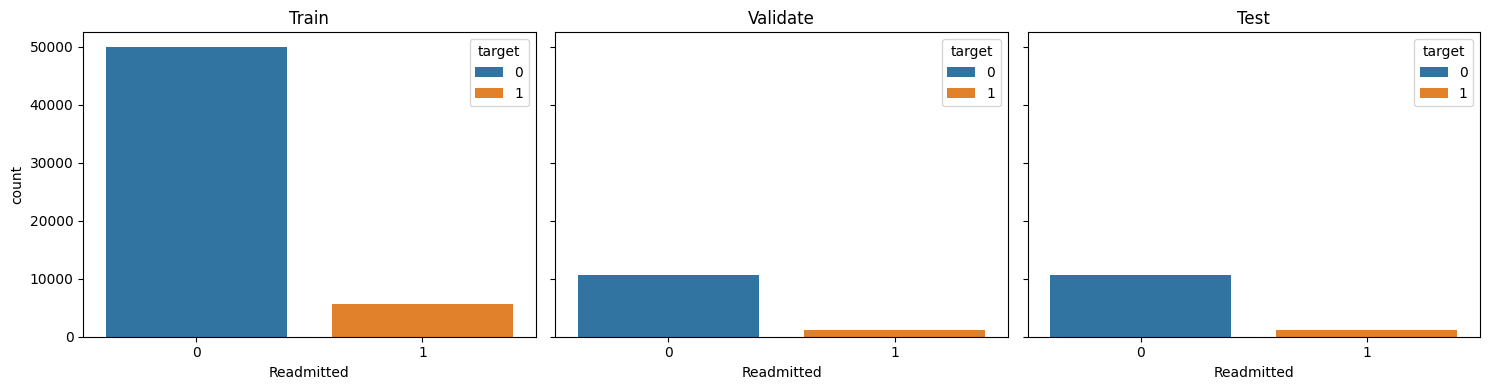

In [4]:
from shared_util.metrics.printing import check_y_dist

check_y_dist(
    y_train,
    y_validate,
    y_test
)

## Baseline

In [22]:
import xgboost as xgb
from imblearn.under_sampling import RandomUnderSampler
from shared_util.pipeline import CleaningPipeline
from shared_util.baseline import get_baseline_score
from imblearn.pipeline import pipeline



In [6]:
print('Baseline boosted tree')

clf = xgb.XGBClassifier(tree_method='hist', eval_metric='auc', n_estimators=600, random_state=42)

# pipe = Pipeline([
#     ('preprocessor', CleaningPipeline(create_interactions=False)),
#     ('sampler', RandomUnderSampler(random_state=42)),
#     ('model', clf)
# ])

# pipe.fit(X_train, y_train)


roc_auc = get_baseline_score(
    clf,
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    preprocessor=CleaningPipeline(create_interactions=True)
    )


if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        notes=METRIC_NOTES,
        model='xgboost',
        data='train',
        pipeline_notes='under_sample',
        roc_auc=roc_auc
    )

Baseline boosted tree
roc_auc score per fold:  [0.60047101 0.6024194  0.58899644 0.61343237 0.59078214]
mean roc_auc score:  0.59922026924701
logged row: (0, xgboost, train, base, under_sample)


In [7]:
from imblearn.over_sampling import SMOTE

clf_smote = xgb.XGBClassifier(tree_method='hist', eval_metric='auc', n_estimators=600, random_state=42)
roc_auc = get_baseline_score(
    clf_smote,
    SMOTE(random_state=42),
    X_train,
    y_train,
    preprocessor=CleaningPipeline(create_interactions=True)
    )

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        notes=METRIC_NOTES,
        model='xgboost',
        data='train',
        pipeline_notes='SMOTE',
        roc_auc=roc_auc
    )


roc_auc score per fold:  [0.57866902 0.57799879 0.56753977 0.58676671 0.57178902]
mean roc_auc score:  0.5765526620064103
logged row: (0, xgboost, train, base, SMOTE)


In [23]:
# manually build out xgb pipe
from imblearn.pipeline import  Pipeline
from scipy.stats import randint as sp_randint, uniform, loguniform

def make_xgb_pipe(model=None):
    return Pipeline([
        ('preprocessor', CleaningPipeline(create_interactions=True)),
        ('model', model if model is not None else xgb.XGBClassifier(
            random_state=42,
            objective='binary:logistic',
            eval_metric='auc',
            tree_method='hist',
            device='cuda',
        ))
    ])

estimator = make_xgb_pipe()

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
approx_spw = float(neg / max(1, pos))

param_dist = {
    'model__n_estimators': sp_randint(200, 1500),
    'model__learning_rate': uniform(0.01, 0.29),
    'model__max_depth': sp_randint(2, 10),
    'model__min_child_weight': sp_randint(1, 10),
    'model__subsample': uniform(0.5, 0.5),
    'model__colsample_bytree': uniform(0.5, 0.5),
    'model__gamma': uniform(0.0, 5.0),
    'model__reg_alpha': loguniform(1e-8, 1e-1),
    'model__reg_lambda': loguniform(1e-2, 10),
    'model__scale_pos_weight': loguniform(max(approx_spw/5, 1e-3), approx_spw*5),
}

print(approx_spw)



8.949373881932022


The below cell uses an f2 (recall weighted score) to prevent the model chosing hyperparameters that end in a model that almost never predicts the positive class (but has the best ROC_AUC we told it to maximize before)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from shared_util.baseline import make_group_cv
from shared_util.metrics.scoring import make_f2_scorer

f2_scorer = make_f2_scorer()

rs = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_dist,
    n_iter=100,                    
    scoring='roc_auc',
    cv=make_group_cv(),            
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

rs.fit(X_train, y_train, groups=X_train['patient_nbr'])

print(f'Best roc_auc (cv): {rs.best_score_}')
print(f'best params: {rs.best_params_}')

res_df = pd.DataFrame(
    rs.cv_results_
).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best roc_auc (cv): 0.6100820477519725
best params: {'model__colsample_bytree': np.float64(0.7159725093210578), 'model__gamma': np.float64(1.4561457009902097), 'model__learning_rate': np.float64(0.18743733946949004), 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 1467, 'model__reg_alpha': np.float64(0.0001402497132660034), 'model__reg_lambda': np.float64(0.013783237455007183), 'model__scale_pos_weight': np.float64(12.65126356046721), 'model__subsample': np.float64(0.5852620618436457)}


,rank_test_score,mean_test_score,std_test_score,params
0,1,0.610082,0.009075,{'model__colsample_bytree': 0.7159725093210578...
1,2,0.595424,0.004187,{'model__colsample_bytree': 0.9211423872974993...
2,3,0.594410,0.005439,{'model__colsample_bytree': 0.6872700594236812...
3,4,0.587717,0.004730,{'model__colsample_bytree': 0.8540362888980227...
4,5,NaN,NaN,{'model__colsample_bytree': 0.5325257964926398...
5,5,NaN,NaN,{'model__colsample_bytree': 0.9165974558680822...
6,5,NaN,NaN,{'model__colsample_bytree': 0.9143687545759647...
7,5,NaN,NaN,{'model__colsample_bytree': 0.5993578407670862...
8,5,NaN,NaN,{'model__colsample_bytree': 0.9315517129377968...
9,5,NaN,NaN,{'model__colsample_bytree': 0.7806217129238506...


In [ ]:
# best params: {'model__colsample_bytree': np.float64(0.7159725093210578), 'model__gamma': np.float64(1.4561457009902097), 'model__learning_rate': np.float64(0.18743733946949004), 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 1467, 'model__reg_alpha': np.float64(0.0001402497132660034), 'model__reg_lambda': np.float64(0.013783237455007183), 'model__scale_pos_weight': np.float64(12.65126356046721), 'model__subsample': np.float64(0.5852620618436457)}


In [24]:
clf_auc_roc_weighted = xgb.XGBClassifier(
    colsample_bytree=0.7159725093210578,
    gamma=1.4561457009902097,
    learning_rate=0.18743733946949004,
    max_depth=3,
    min_child_weight=3,
    n_estimators=1467,
    reg_alpha=0.0001402497132660034,
    reg_lambda=0.013783237455007183,
    scale_pos_weight=12.65126356046721,
    subsample=0.5852620618436457,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

clf_f2_weighted = xgb.XGBClassifier(
        colsample_bytree=float(0.5100355988888632),
        gamma=float(1.6103958279158914),
        learning_rate=float(0.07131992202899794),
        max_depth=3,
        min_child_weight=9,
        n_estimators=344,
        reg_alpha=float(2.5147108172305717e-06),
        reg_lambda=float(0.2641860151813427),
        scale_pos_weight=float(4.979176466085375),
        subsample=float(0.8244114201457879),
        random_state=42
    )

USE_F2 = False

try:
    xgb_est = rs.best_estimator_
except:
    xgb_est = make_xgb_pipe(clf_f2_weighted if USE_F2 else clf_auc_roc_weighted)
    xgb_est.fit(X_train, y_train)


In [ ]:
from shared_util.metrics.scoring import get_scores
from shared_util.metrics.printing import print_metrics

xgb_scores = get_scores(xgb_est, X_validate)

y_pred = xgb_est.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=xgb_scores,
              data='validate',
              run_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='xgboost',
              hyperparam_notes=f'tuned best {('F2' if USE_F2 else 'roc_auc')}',
              pipeline_notes='under_sample',
              log=LOG
)

ROC_AUC:     0.6105393005566978
Accuracy:      0.5872762417009832
F1 score:      0.22010481181515007
Precision:     0.1361760660247593
Recall:        0.5736754966887417

Confusion matrix:

TN: 6295, FP: 4396, FN: 515, TP: 693

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.59      0.72     10691
           1       0.14      0.57      0.22      1208

    accuracy                           0.59     11899
   macro avg       0.53      0.58      0.47     11899
weighted avg       0.84      0.59      0.67     11899

logged row: (0, xgboost, validate, base, under_sample)


Best threshold (F2): 0.3404
Precision: 0.118  Recall: 0.796  F2: 0.370


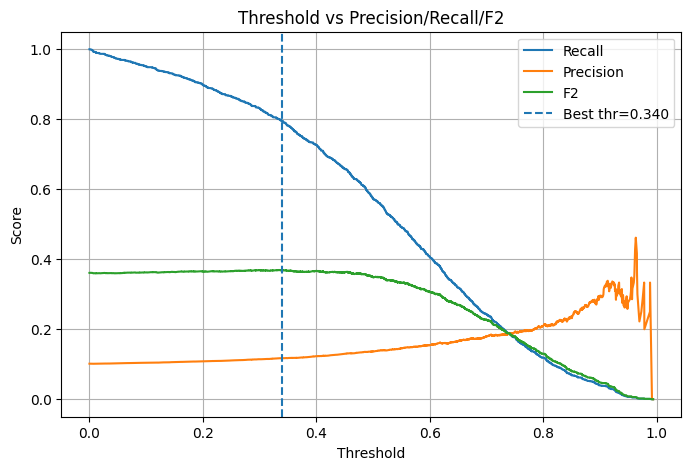

In [ ]:
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring

xgb_scores_val = get_scores(rs.best_estimator_, X_validate)
info = best_threshold_by_fbeta(y_validate, xgb_scores_val)

best_thresh = info["threshold"]


print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [ ]:
xgb_scores_test = get_scores(xgb_est, X_test)

y_pred_test = xgb_est.predict(X_test) #type: ignore
y_pred_custom = (xgb_scores_test >= best_thresh).astype(int)
print_metrics(
              y_true=y_test, 
              y_pred=y_pred_custom, 
              y_proba=xgb_scores_test,
              data='test',
              threshold_notes='f2_weighted',
              run_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='xgboost',
              hyperparam_notes='tuned best F2',
              pipeline_notes='under_sample',
              log=LOG
              )

ROC_AUC:     0.6339347261168367
Accuracy:      0.3723287439817552
F1 score:      0.19586624824153231
Precision:     0.11186650185414092
Recall:        0.7862728062554301

Confusion matrix:

TN: 3503, FP: 7185, FN: 246, TP: 905

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.33      0.49     10688
           1       0.11      0.79      0.20      1151

    accuracy                           0.37     11839
   macro avg       0.52      0.56      0.34     11839
weighted avg       0.85      0.37      0.46     11839

logged row: (0, xgboost, test, f2_weighted, under_sample)


In [14]:
metrics_db.close(write=True)